# **Random Forest Classifier — Hotel Booking Cancellation Prediction**

This notebook covers the full RF modelling pipeline:
1. Data loading & preprocessing
2. Six sampling strategies compared
3. RandomizedSearchCV hyperparameter tuning on best method
4. Final model evaluation
5. Feature importance analysis

---
## **1. Imports**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, f1_score,
                             recall_score, precision_score)
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

print("All libraries imported successfully")

All libraries imported successfully


---
## **2. Preprocessing — Log Transform + Hybrid Encoding**

In [ ]:
# ============================================================
# PREPROCESSING — Hybrid Encoding (no log transform needed for RF)
# ============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

train = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_train.csv")
val   = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_validation.csv")
test  = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_test.csv")

# STEP 1 — Binary Encoding
binary_cols = ["Gender", "Previous_Cancellations", "Visted_Previously",
               "Use_Promotion", "Required_Car_Parking"]
le = LabelEncoder()
for col in binary_cols:
    le.fit(train[col].astype(str))
    train[col] = le.transform(train[col].astype(str))
    val[col]   = le.transform(val[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

print("Binary encoding done")

# STEP 2 — Ordinal Encoding
income_order = [["<25K", "25K --50K", "50K -- 100K", ">100K"]]
edu_order    = [["Mid-School", "High-School", "College", "Grad"]]

oe_income = OrdinalEncoder(categories=income_order,
                            handle_unknown="use_encoded_value",
                            unknown_value=-1)
oe_income.fit(train[["Income"]])
train["Income"] = oe_income.transform(train[["Income"]])
val["Income"]   = oe_income.transform(val[["Income"]])
test["Income"]  = oe_income.transform(test[["Income"]])

oe_edu = OrdinalEncoder(categories=edu_order,
                         handle_unknown="use_encoded_value",
                         unknown_value=-1)
oe_edu.fit(train[["Educational_Level"]])
train["Educational_Level"] = oe_edu.transform(train[["Educational_Level"]])
val["Educational_Level"]   = oe_edu.transform(val[["Educational_Level"]])
test["Educational_Level"]  = oe_edu.transform(test[["Educational_Level"]])

print("Ordinal encoding done")

# STEP 3 — Target Encoding for Meal_Type (fit on train only)
meal_target_map = (
    train.groupby("Meal_Type")["Reservation_Status"]
    .apply(lambda x: (x != "Check-In").mean())
    .to_dict()
)
print(f"Meal_Type target encoding map: {meal_target_map}")

train["Meal_Type"] = train["Meal_Type"].map(meal_target_map)
val["Meal_Type"]   = val["Meal_Type"].map(meal_target_map)
test["Meal_Type"]  = test["Meal_Type"].map(meal_target_map).fillna(
    train["Meal_Type"].mean())

print("Target encoding done")

# STEP 4 — OHE
ohe_cols = ["Hotel_Type", "Booking_channel", "Deposit_type",
            "Ethnicity", "Country_region"]

train = pd.get_dummies(train, columns=ohe_cols, drop_first=True)
val   = pd.get_dummies(val,   columns=ohe_cols, drop_first=True)
test  = pd.get_dummies(test,  columns=ohe_cols, drop_first=True)

val  = val.reindex(columns=train.columns, fill_value=0)
test = test.reindex(columns=train.columns, fill_value=0)

# Clean column names for XGBoost compatibility
for frame in [train, val, test]:
    frame.columns = frame.columns.str.replace("[","",regex=False)\
                                  .str.replace("]","",regex=False)\
                                  .str.replace("<","",regex=False)\
                                  .str.replace(">","",regex=False)\
                                  .str.replace(",","",regex=False)\
                                  .str.replace(" ","_",regex=False)\
                                  .str.replace("-","_",regex=False)

val  = val.reindex(columns=train.columns, fill_value=0)
test = test.reindex(columns=train.columns, fill_value=0)

print(f"\nPreprocessing complete")
print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

Binary encoding done
Ordinal encoding done
Meal_Type target encoding map: {'BB': 0.15960514640638865, 'FB': 0.3828125, 'HB': 0.2543086939869782}
Target encoding done

Preprocessing complete
Train: (17694, 35) | Val: (1784, 35) | Test: (2793, 35)


---
## **3. Encode Target & Prepare X, y**

In [ ]:
le_target = LabelEncoder()
le_target.fit(train["Reservation_Status"])

y_train = le_target.transform(train["Reservation_Status"])
y_val   = le_target.transform(val["Reservation_Status"])

print("Classes:", le_target.classes_)
# Should be: ['Canceled' 'Check-In' 'No-Show'] → 0, 1, 2

drop_cols = [c for c in ["Reservation_Status", "Booking_date",
                          "Expected_checkin", "Expected_checkout",
                          "Reservation_ID"]
             if c in train.columns]

X_train = train.drop(columns=drop_cols).astype(float)
X_val   = val.drop(columns=drop_cols).astype(float)
X_test  = test.drop(columns=[c for c in drop_cols
                              if c in test.columns]).astype(float)

y_val_bin = label_binarize(y_val, classes=[0, 1, 2])

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\nTrain class distribution:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_train == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nVal class distribution:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_val == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_val)*100:.1f}%)")

Classes: ['Canceled' 'Check-In' 'No-Show']

X_train: (17694, 34)
X_val:   (1784, 34)
X_test:  (2793, 34)

Train class distribution:
  Canceled: 2724 (15.4%)
  Check-In: 13604 (76.9%)
  No-Show: 1366 (7.7%)

Val class distribution:
  Canceled: 491 (27.5%)
  Check-In: 1041 (58.4%)
  No-Show: 252 (14.1%)


---
## **4. Evaluation Function**

In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob, y_true_bin, classes):

    acc       = round(accuracy_score(y_true, y_pred), 4)
    prec      = round(precision_score(y_true, y_pred,
                      average="macro", zero_division=0), 4)
    recall    = round(recall_score(y_true, y_pred, average="macro"), 4)
    f1        = round(f1_score(y_true, y_pred, average="macro"), 4)
    auc       = round(roc_auc_score(y_true_bin, y_prob,
                      multi_class="ovr"), 4)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc}")
    print(f"  Precision : {prec}")
    print(f"  Recall    : {recall}")
    print(f"  F1 Macro  : {f1}")
    print(f"  ROC-AUC   : {auc}")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=classes)
    plt.figure(figsize=(8, 6))
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {name}", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ROC Curve
    colors = ["steelblue", "orange", "green"]
    plt.figure(figsize=(9, 6))
    for i, (color, cls) in enumerate(zip(colors, classes)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_cls = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{cls} (AUC={auc_cls:.3f})")
    plt.plot([0,1],[0,1],"r--", label="Random Guess")
    plt.title(f"ROC Curve — {name}", fontsize=13)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": recall, "f1_macro": f1, "roc_auc": auc}

print("Evaluation function ready")

Evaluation function ready


---
## **5. Sampling Strategy Comparison**

We test 6 approaches. Key change from previous attempts: we remove the heavy regularization (`max_depth=15`, `min_samples_leaf=10`) that was preventing the model from learning minority classes. We use `max_depth=None` and `min_samples_leaf=2` to let the trees grow freely first, then regularize later during hyperparameter tuning.

In [ ]:
# Store all results
results = []

### **5.1 Baseline (no balancing)**


  RF Baseline
  Accuracy  : 0.5835
  Precision : 0.1945
  Recall    : 0.3333
  F1 Macro  : 0.2457
  ROC-AUC   : 0.5137

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.00      0.00      0.00       491
    Check-In       0.58      1.00      0.74      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.19      0.33      0.25      1784
weighted avg       0.34      0.58      0.43      1784



<Figure size 800x600 with 0 Axes>

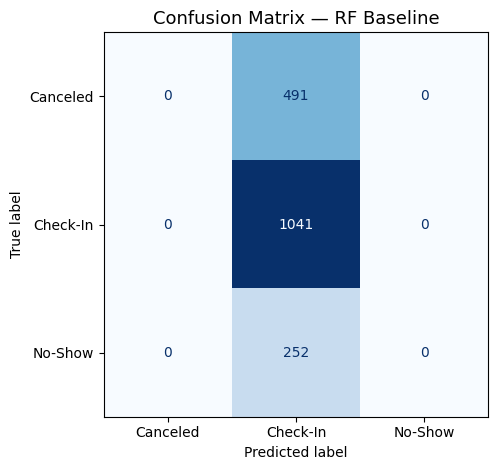

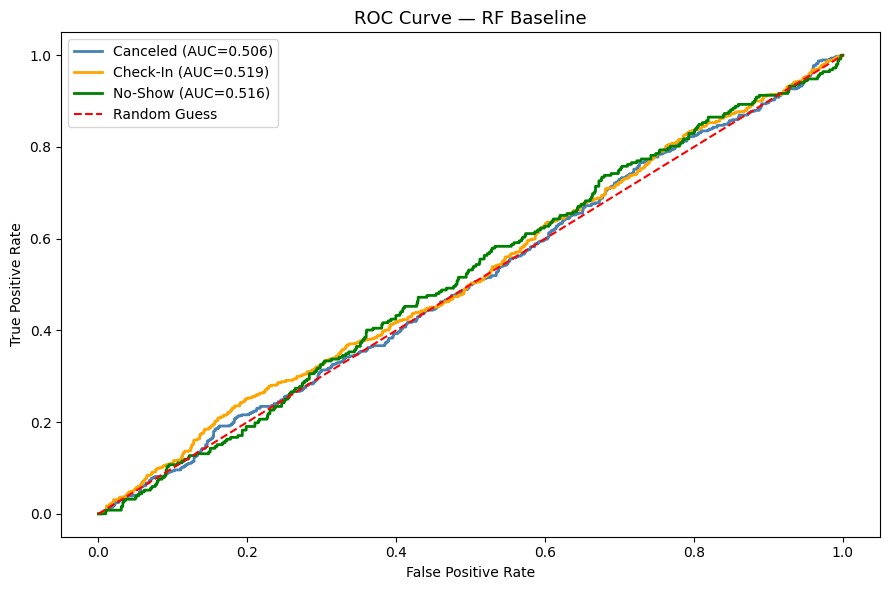

In [ ]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)
y_pred = rf_baseline.predict(X_val)
y_prob = rf_baseline.predict_proba(X_val)

metrics = evaluate_model("RF Baseline", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **5.2 SMOTE**

After SMOTE:
  Canceled: 13604 (33.3%)
  Check-In: 13604 (33.3%)
  No-Show: 13604 (33.3%)

  RF SMOTE
  Accuracy  : 0.5841
  Precision : 0.5279
  Recall    : 0.334
  F1 Macro  : 0.2471
  ROC-AUC   : 0.5197

Classification Report:
              precision    recall  f1-score   support

    Canceled       1.00      0.00      0.00       491
    Check-In       0.58      1.00      0.74      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.53      0.33      0.25      1784
weighted avg       0.62      0.58      0.43      1784



<Figure size 800x600 with 0 Axes>

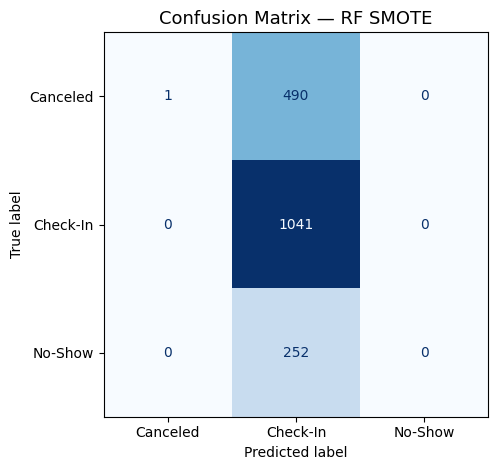

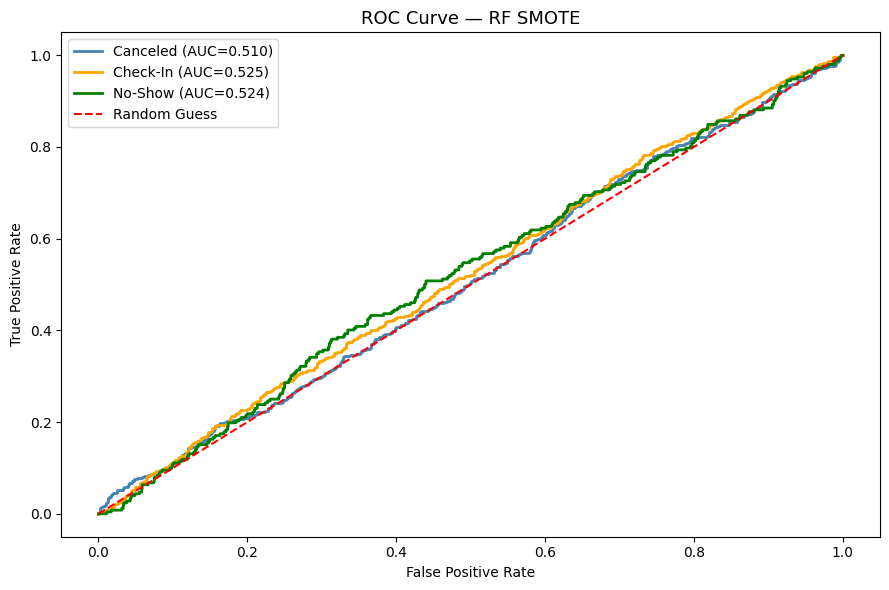

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_train_smote == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_train_smote)*100:.1f}%)")

rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)
y_pred = rf_smote.predict(X_val)
y_prob = rf_smote.predict_proba(X_val)

metrics = evaluate_model("RF SMOTE", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **5.3 Random Undersampling**

After Undersampling:
  Canceled: 1366 (33.3%)
  Check-In: 1366 (33.3%)
  No-Show: 1366 (33.3%)

  RF Undersampling
  Accuracy  : 0.3296
  Precision : 0.3486
  Recall    : 0.3476
  F1 Macro  : 0.3106
  ROC-AUC   : 0.5128

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.29      0.30      0.29       491
    Check-In       0.61      0.32      0.42      1041
     No-Show       0.15      0.42      0.22       252

    accuracy                           0.33      1784
   macro avg       0.35      0.35      0.31      1784
weighted avg       0.46      0.33      0.36      1784



<Figure size 800x600 with 0 Axes>

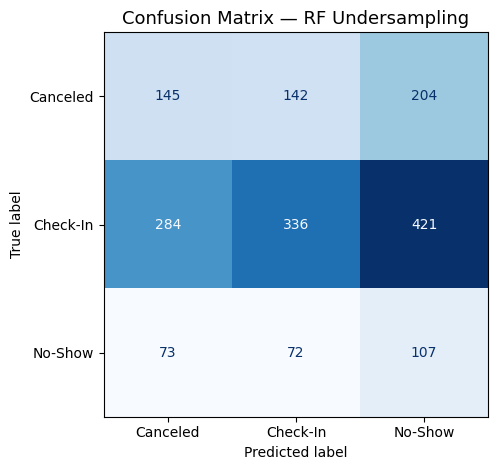

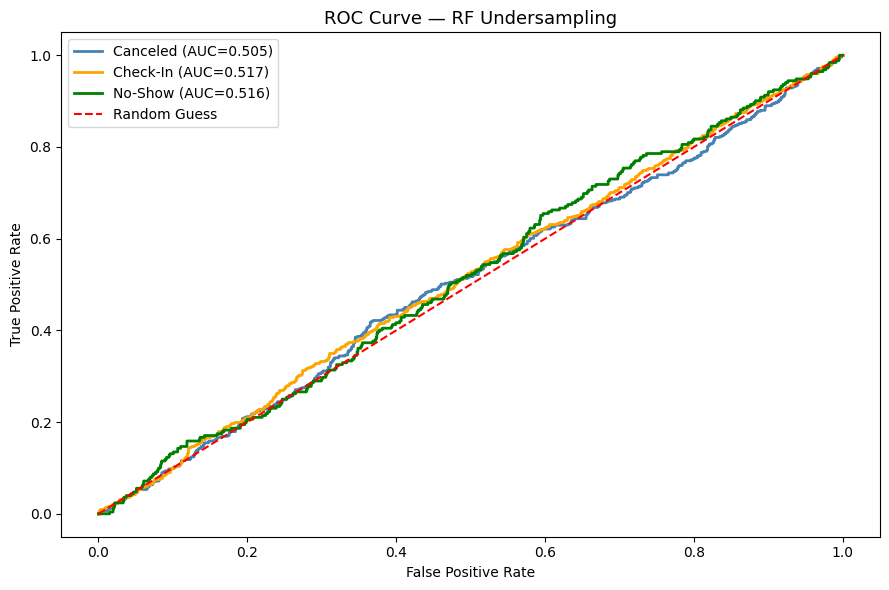

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("After Undersampling:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_train_rus == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_train_rus)*100:.1f}%)")

rf_rus = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_rus.fit(X_train_rus, y_train_rus)
y_pred = rf_rus.predict(X_val)
y_prob = rf_rus.predict_proba(X_val)

metrics = evaluate_model("RF Undersampling", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **5.4 Class Weighting Only**


  RF Class Weight
  Accuracy  : 0.5835
  Precision : 0.1945
  Recall    : 0.3333
  F1 Macro  : 0.2457
  ROC-AUC   : 0.5167

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.00      0.00      0.00       491
    Check-In       0.58      1.00      0.74      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.19      0.33      0.25      1784
weighted avg       0.34      0.58      0.43      1784



<Figure size 800x600 with 0 Axes>

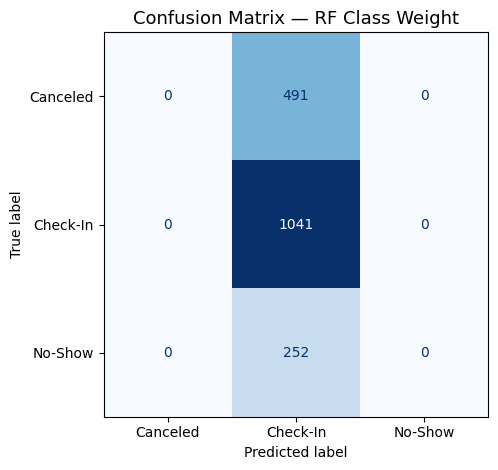

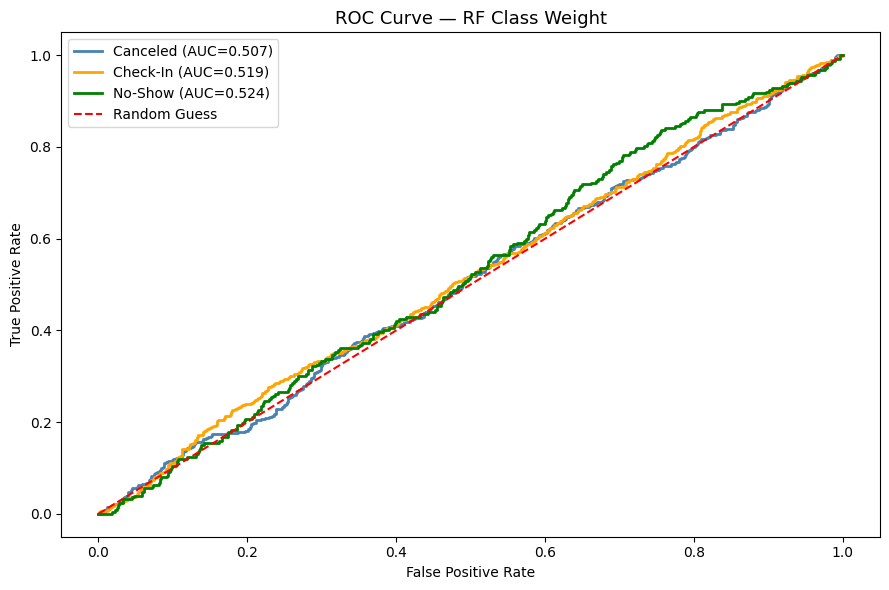

In [ ]:
rf_cw = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    random_state=42,
    n_jobs=-1
)

rf_cw.fit(X_train, y_train)
y_pred = rf_cw.predict(X_val)
y_prob = rf_cw.predict_proba(X_val)

metrics = evaluate_model("RF Class Weight", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **5.5 Hybrid Sampling (Match Validation Distribution)**

After Hybrid Sampling:
  Canceled: 4000 (28.6%)
  Check-In: 8000 (57.1%)
  No-Show: 2000 (14.3%)

  RF Hybrid Sampling
  Accuracy  : 0.5852
  Precision : 0.5282
  Recall    : 0.3354
  F1 Macro  : 0.25
  ROC-AUC   : 0.5233

Classification Report:
              precision    recall  f1-score   support

    Canceled       1.00      0.01      0.01       491
    Check-In       0.58      1.00      0.74      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.59      1784
   macro avg       0.53      0.34      0.25      1784
weighted avg       0.62      0.59      0.43      1784



<Figure size 800x600 with 0 Axes>

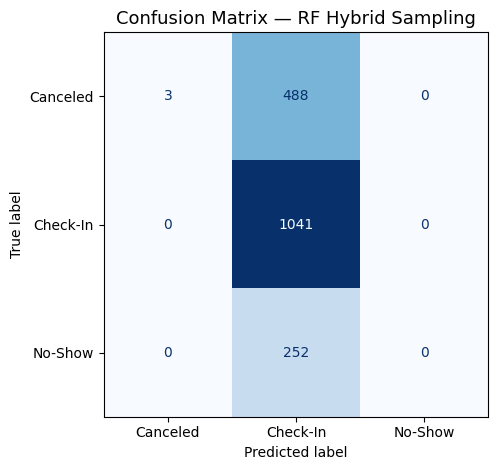

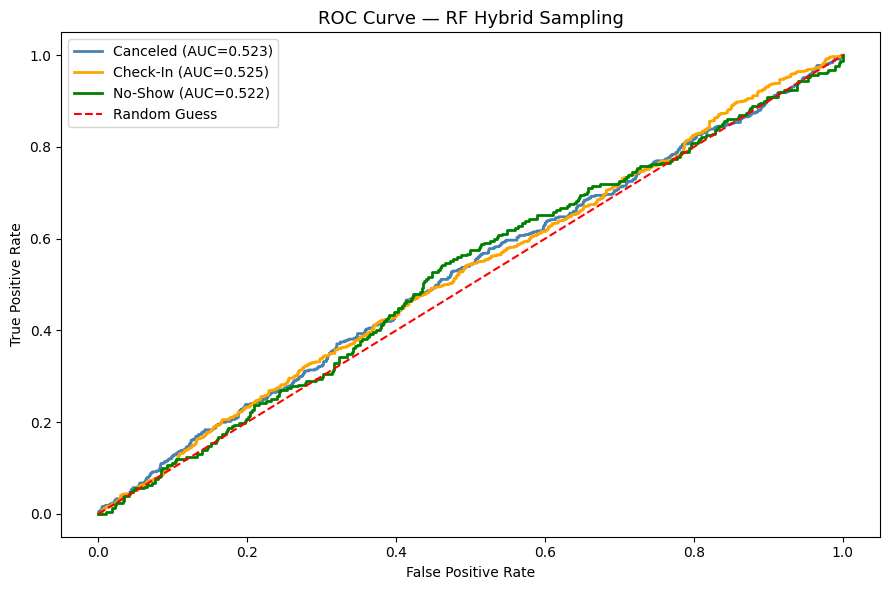

In [ ]:
oversample = SMOTE(
    sampling_strategy={0: 4000, 2: 2000},
    random_state=42, k_neighbors=5
)
undersample = RandomUnderSampler(
    sampling_strategy={1: 8000},
    random_state=42
)
hybrid_pipe = Pipeline([
    ("smote", oversample),
    ("undersample", undersample)
])

X_train_hybrid, y_train_hybrid = hybrid_pipe.fit_resample(X_train, y_train)

print("After Hybrid Sampling:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_train_hybrid == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_train_hybrid)*100:.1f}%)")

rf_hybrid = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_hybrid.fit(X_train_hybrid, y_train_hybrid)
y_pred = rf_hybrid.predict(X_val)
y_prob = rf_hybrid.predict_proba(X_val)

metrics = evaluate_model("RF Hybrid Sampling", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **5.6 Hybrid Sampling + Class Weights Combined**

This combines both strategies — resample to approximate validation distribution, then also apply class weights so the model penalises minority misclassification even harder.


  RF Hybrid + Class Weight
  Accuracy  : 0.5734
  Precision : 0.2932
  Recall    : 0.3355
  F1 Macro  : 0.2688
  ROC-AUC   : 0.5132

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.29      0.04      0.08       491
    Check-In       0.59      0.96      0.73      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.57      1784
   macro avg       0.29      0.34      0.27      1784
weighted avg       0.42      0.57      0.45      1784



<Figure size 800x600 with 0 Axes>

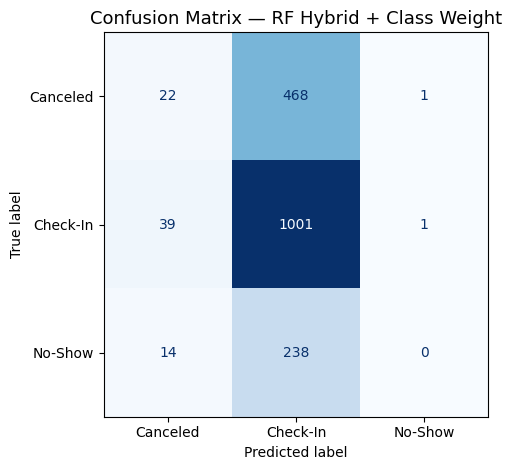

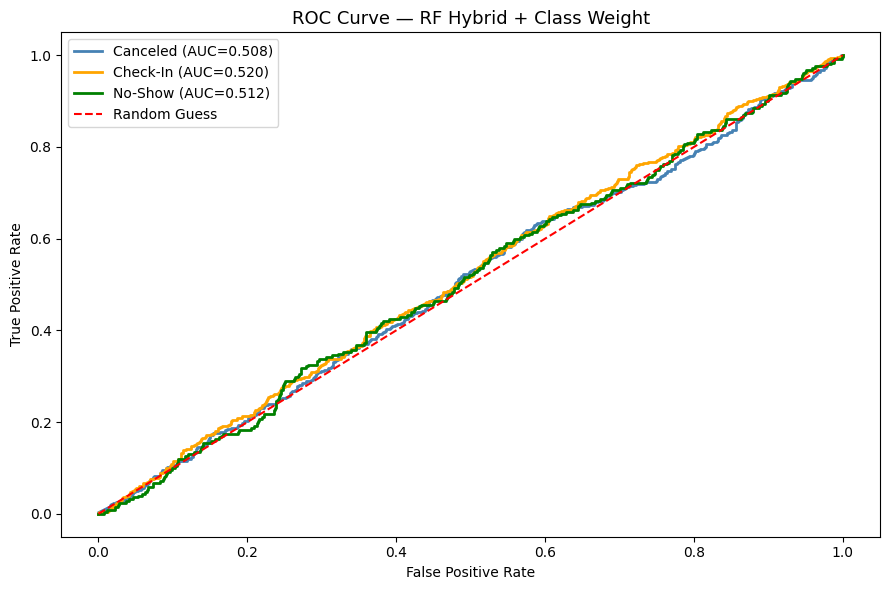

In [ ]:
rf_hybrid_cw = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    random_state=42,
    n_jobs=-1
)

# Use the hybrid sampled data from the previous cell
rf_hybrid_cw.fit(X_train_hybrid, y_train_hybrid)
y_pred = rf_hybrid_cw.predict(X_val)
y_prob = rf_hybrid_cw.predict_proba(X_val)

metrics = evaluate_model("RF Hybrid + Class Weight", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)


  RF Aggressive Weights
  Accuracy  : 0.5835
  Precision : 0.1945
  Recall    : 0.3333
  F1 Macro  : 0.2457
  ROC-AUC   : 0.5229

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.00      0.00      0.00       491
    Check-In       0.58      1.00      0.74      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.19      0.33      0.25      1784
weighted avg       0.34      0.58      0.43      1784



<Figure size 800x600 with 0 Axes>

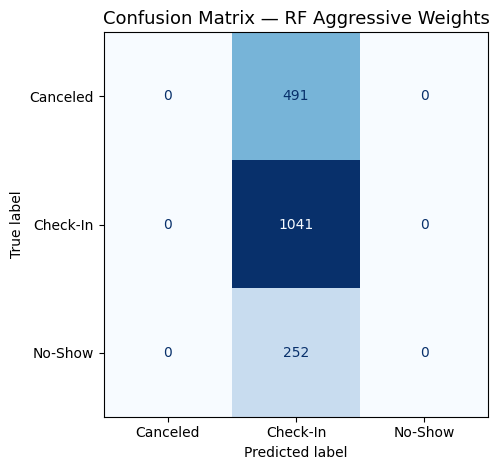

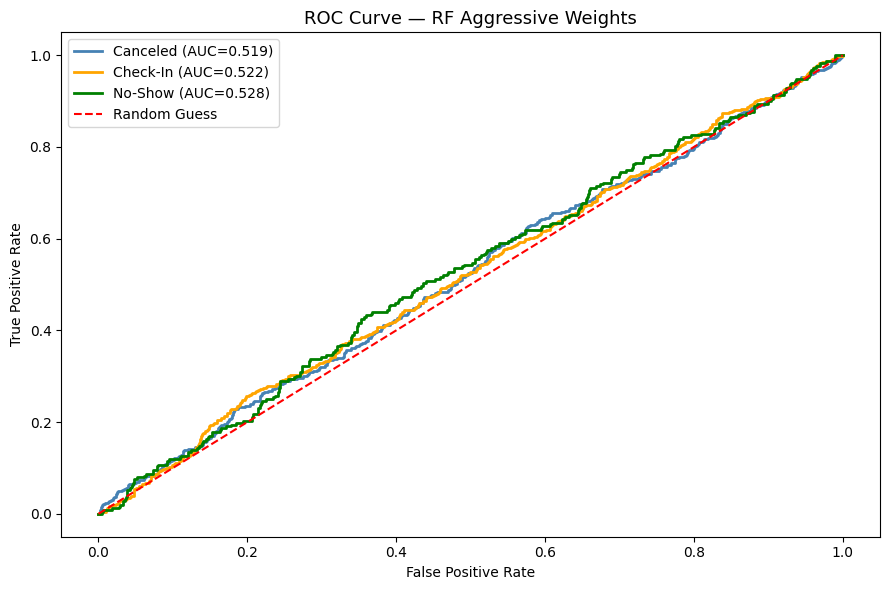

In [ ]:
rf_cw_aggressive = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight={0: 5.0, 1: 1.0, 2: 7.0},
    random_state=42,
    n_jobs=-1
)

rf_cw_aggressive.fit(X_train, y_train)
y_pred = rf_cw_aggressive.predict(X_val)
y_prob = rf_cw_aggressive.predict_proba(X_val)

metrics = evaluate_model("RF Aggressive Weights", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)


  RF Balanced Subsample
  Accuracy  : 0.5835
  Precision : 0.1945
  Recall    : 0.3333
  F1 Macro  : 0.2457
  ROC-AUC   : 0.5226

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.00      0.00      0.00       491
    Check-In       0.58      1.00      0.74      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.19      0.33      0.25      1784
weighted avg       0.34      0.58      0.43      1784



<Figure size 800x600 with 0 Axes>

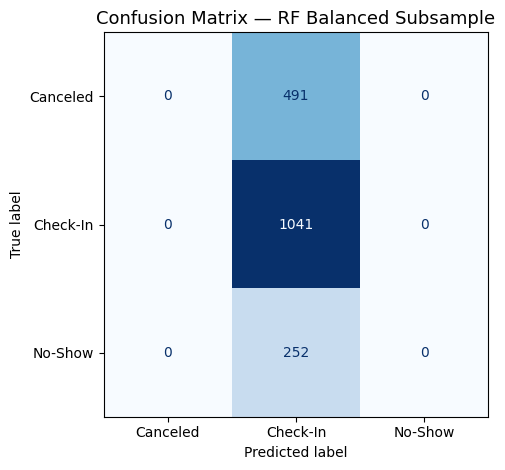

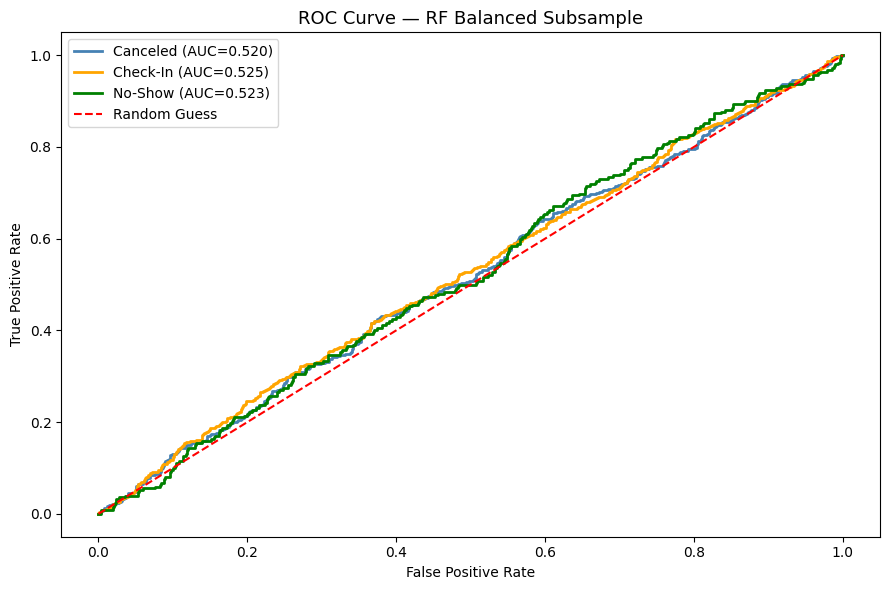

In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)
y_pred = rf_balanced.predict(X_val)
y_prob = rf_balanced.predict_proba(X_val)

metrics = evaluate_model("RF Balanced Subsample", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

After Exact Val Distribution Match:
  Canceled: 2750 (27.5%)
  Check-In: 5840 (58.4%)
  No-Show: 1410 (14.1%)

  RF Exact Val Match
  Accuracy  : 0.5717
  Precision : 0.2903
  Recall    : 0.3356
  F1 Macro  : 0.2711
  ROC-AUC   : 0.5213

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.28      0.05      0.09       491
    Check-In       0.59      0.96      0.73      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.57      1784
   macro avg       0.29      0.34      0.27      1784
weighted avg       0.42      0.57      0.45      1784



<Figure size 800x600 with 0 Axes>

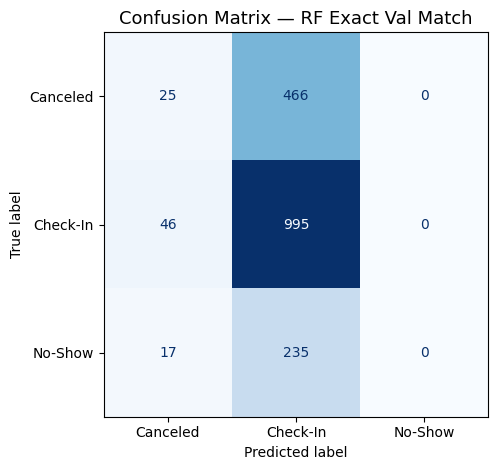

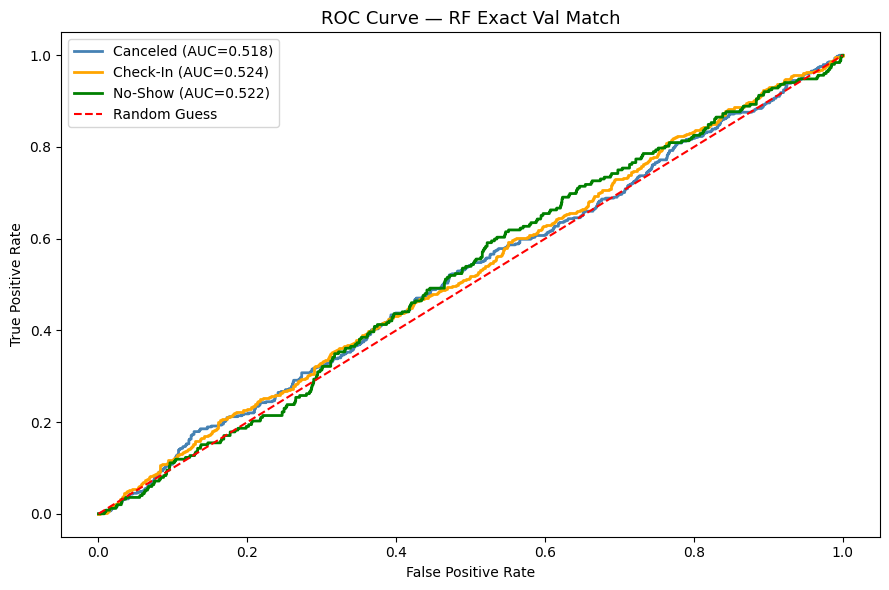

In [ ]:
# Exact validation distribution: 27.5% Canceled, 58.4% Check-In, 14.1% No-Show
# Scale to ~10000 total: Canceled=2750, Check-In=5840, No-Show=1410

oversample_exact = SMOTE(
    sampling_strategy={0: 2750, 2: 1410},
    random_state=42, k_neighbors=5
)
undersample_exact = RandomUnderSampler(
    sampling_strategy={1: 5840},
    random_state=42
)
exact_pipe = Pipeline([
    ("smote", oversample_exact),
    ("undersample", undersample_exact)
])

X_train_exact, y_train_exact = exact_pipe.fit_resample(X_train, y_train)

print("After Exact Val Distribution Match:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_train_exact == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_train_exact)*100:.1f}%)")

rf_exact = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_exact.fit(X_train_exact, y_train_exact)
y_pred = rf_exact.predict(X_val)
y_prob = rf_exact.predict_proba(X_val)

metrics = evaluate_model("RF Exact Val Match", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)


  RF Exact Match + CW
  Accuracy  : 0.5303
  Precision : 0.2857
  Recall    : 0.333
  F1 Macro  : 0.2986
  ROC-AUC   : 0.5225

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.27      0.17      0.21       491
    Check-In       0.59      0.83      0.69      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.53      1784
   macro avg       0.29      0.33      0.30      1784
weighted avg       0.42      0.53      0.46      1784



<Figure size 800x600 with 0 Axes>

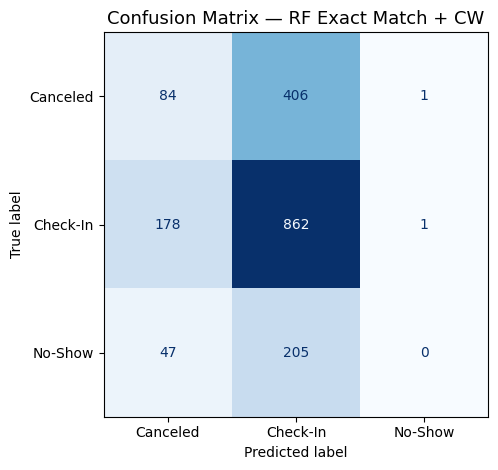

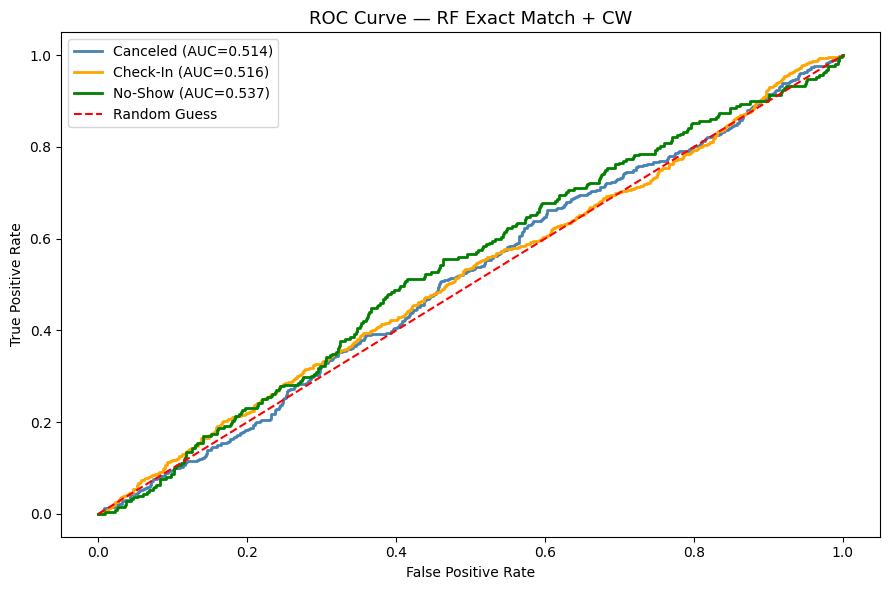

In [ ]:
rf_exact_cw = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    random_state=42,
    n_jobs=-1
)

rf_exact_cw.fit(X_train_exact, y_train_exact)
y_pred = rf_exact_cw.predict(X_val)
y_prob = rf_exact_cw.predict_proba(X_val)

metrics = evaluate_model("RF Exact Match + CW", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)


  RF Undersample + CW
  Accuracy  : 0.2029
  Precision : 0.3238
  Recall    : 0.3198
  F1 Macro  : 0.2024
  ROC-AUC   : 0.5083

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.24      0.31      0.27       491
    Check-In       0.59      0.06      0.11      1041
     No-Show       0.14      0.59      0.23       252

    accuracy                           0.20      1784
   macro avg       0.32      0.32      0.20      1784
weighted avg       0.43      0.20      0.17      1784



<Figure size 800x600 with 0 Axes>

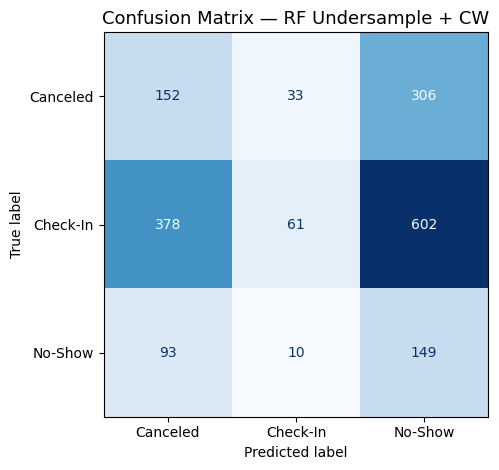

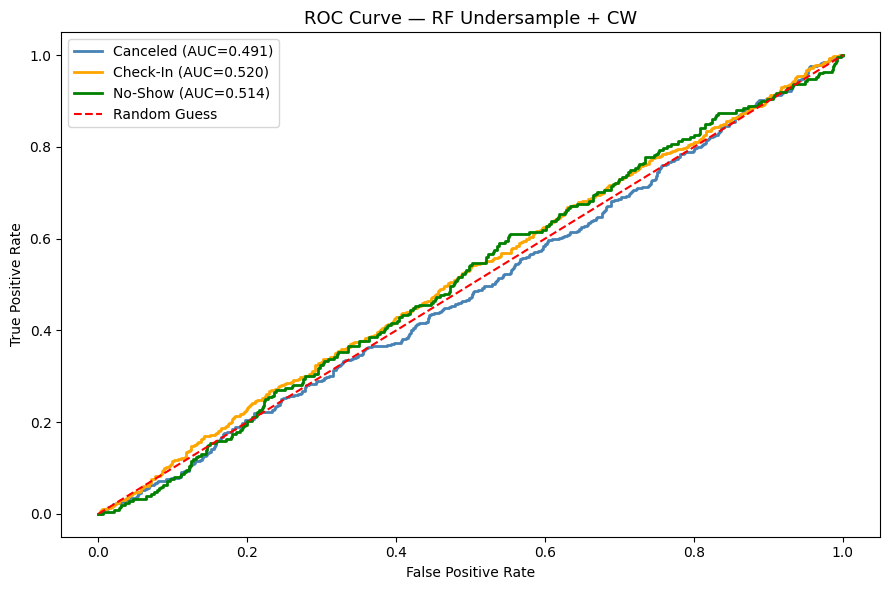

In [ ]:
rf_rus_cw = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    random_state=42,
    n_jobs=-1
)

rf_rus_cw.fit(X_train_rus, y_train_rus)
y_pred = rf_rus_cw.predict(X_val)
y_prob = rf_rus_cw.predict_proba(X_val)

metrics = evaluate_model("RF Undersample + CW", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)


  RF SMOTE + CW
  Accuracy  : 0.5757
  Precision : 0.2911
  Recall    : 0.3314
  F1 Macro  : 0.2524
  ROC-AUC   : 0.51

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.29      0.01      0.03       491
    Check-In       0.58      0.98      0.73      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.29      0.33      0.25      1784
weighted avg       0.42      0.58      0.43      1784



<Figure size 800x600 with 0 Axes>

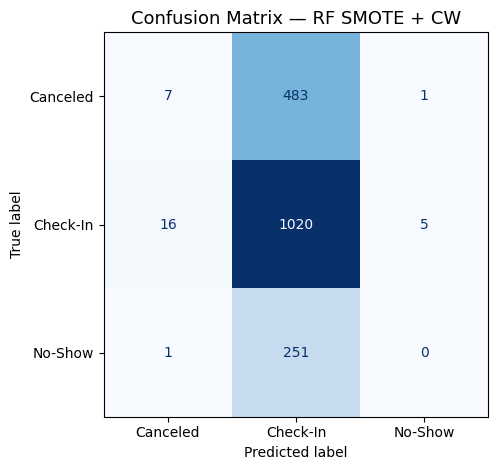

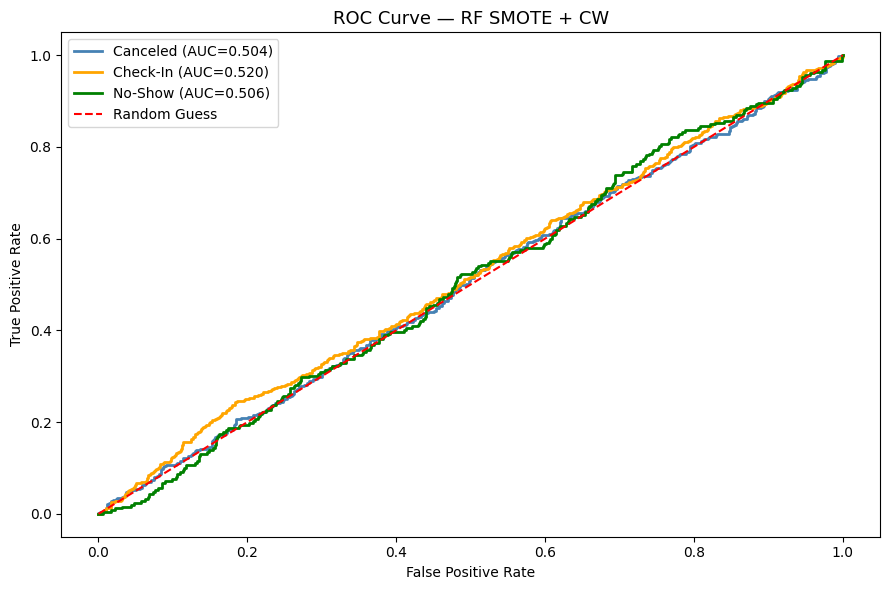

In [ ]:
rf_smote_cw = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    random_state=42,
    n_jobs=-1
)

rf_smote_cw.fit(X_train_smote, y_train_smote)
y_pred = rf_smote_cw.predict(X_val)
y_prob = rf_smote_cw.predict_proba(X_val)

metrics = evaluate_model("RF SMOTE + CW", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

---
## **6. Sampling Comparison Table**

In [ ]:
results_df = pd.DataFrame(results)

print("=" * 90)
print("       RF — SAMPLING METHOD COMPARISON")
print("=" * 90)
print(f"{'Model':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1 Macro':>9} {'ROC-AUC':>9}")
print("-" * 90)
for _, row in results_df.iterrows():
    print(f"{row['name']:<28} {row['accuracy']:>9} {row['precision']:>10} {row['recall']:>8} {row['f1_macro']:>9} {row['roc_auc']:>9}")
print("=" * 90)

# Highlight best method
best_idx = results_df["f1_macro"].idxmax()
best_method = results_df.loc[best_idx, "name"]
print(f"\nBest method by F1 Macro: {best_method} ({results_df.loc[best_idx, 'f1_macro']})")
print(f"Best method by Recall:   {results_df.loc[results_df['recall'].idxmax(), 'name']} ({results_df['recall'].max()})")
print(f"Best method by ROC-AUC:  {results_df.loc[results_df['roc_auc'].idxmax(), 'name']} ({results_df['roc_auc'].max()})")

       RF — SAMPLING METHOD COMPARISON
Model                         Accuracy  Precision   Recall  F1 Macro   ROC-AUC
------------------------------------------------------------------------------------------
RF Baseline                     0.5835     0.1945   0.3333    0.2457    0.5137
RF SMOTE                        0.5841     0.5279    0.334    0.2471    0.5197
RF Undersampling                0.3296     0.3486   0.3476    0.3106    0.5128
RF Class Weight                 0.5835     0.1945   0.3333    0.2457    0.5167
RF Hybrid Sampling              0.5852     0.5282   0.3354      0.25    0.5233
RF Hybrid + Class Weight        0.5734     0.2932   0.3355    0.2688    0.5132

Best method by F1 Macro: RF Undersampling (0.3106)
Best method by Recall:   RF Undersampling (0.3476)
Best method by ROC-AUC:  RF Hybrid Sampling (0.5233)


In [ ]:
# Make sure results list has everything — rebuild if needed
results_df = pd.DataFrame(results)

print("=" * 95)
print("       RF — FULL SAMPLING METHOD COMPARISON")
print("=" * 95)
print(f"{'Model':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1 Macro':>9} {'ROC-AUC':>9}")
print("-" * 95)
for _, row in results_df.iterrows():
    print(f"{row['name']:<28} {row['accuracy']:>9} {row['precision']:>10} {row['recall']:>8} {row['f1_macro']:>9} {row['roc_auc']:>9}")
print("=" * 95)

# Highlight best across key metrics
print(f"\nBest by F1 Macro:  {results_df.loc[results_df['f1_macro'].idxmax(), 'name']} ({results_df['f1_macro'].max()})")
print(f"Best by Recall:    {results_df.loc[results_df['recall'].idxmax(), 'name']} ({results_df['recall'].max()})")
print(f"Best by ROC-AUC:   {results_df.loc[results_df['roc_auc'].idxmax(), 'name']} ({results_df['roc_auc'].max()})")
print(f"Best by Precision: {results_df.loc[results_df['precision'].idxmax(), 'name']} ({results_df['precision'].max()})")

       RF — FULL SAMPLING METHOD COMPARISON
Model                         Accuracy  Precision   Recall  F1 Macro   ROC-AUC
-----------------------------------------------------------------------------------------------
RF Baseline                     0.5835     0.1945   0.3333    0.2457    0.5137
RF SMOTE                        0.5841     0.5279    0.334    0.2471    0.5197
RF Undersampling                0.3296     0.3486   0.3476    0.3106    0.5128
RF Class Weight                 0.5835     0.1945   0.3333    0.2457    0.5167
RF Hybrid Sampling              0.5852     0.5282   0.3354      0.25    0.5233
RF Hybrid + Class Weight        0.5734     0.2932   0.3355    0.2688    0.5132
RF Aggressive Weights           0.5835     0.1945   0.3333    0.2457    0.5229
RF Balanced Subsample           0.5835     0.1945   0.3333    0.2457    0.5226
RF Exact Val Match              0.5717     0.2903   0.3356    0.2711    0.5213
RF Exact Match + CW             0.5303     0.2857    0.333    0.2986  

---
## **7. RandomizedSearchCV — Hyperparameter Tuning**

Run this on whichever sampling method won above. **Update the `X_tune` and `y_tune` variables below** based on the comparison table results. The cell defaults to hybrid sampling + class weights as a starting point — change if a different method won.

In [ ]:
# ============================================================
# SET THESE based on comparison table results
# ============================================================
# If Hybrid + Class Weight won:
X_tune = X_train_hybrid
y_tune = y_train_hybrid
use_class_weight = {0: 3.0, 1: 1.0, 2: 4.0}

# If plain Hybrid won, uncomment these instead:
# X_tune = X_train_hybrid
# y_tune = y_train_hybrid
# use_class_weight = None

# If Undersampling won, uncomment these instead:
# X_tune = X_train_rus
# y_tune = y_train_rus
# use_class_weight = None

# If Class Weight only won, uncomment these instead:
# X_tune = X_train
# y_tune = y_train
# use_class_weight = {0: 3.0, 1: 1.0, 2: 4.0}

# If SMOTE won, uncomment these instead:
# X_tune = X_train_smote
# y_tune = y_train_smote
# use_class_weight = None

print(f"Tuning on: {len(X_tune)} samples")
print(f"Class weight: {use_class_weight}")

Tuning on: 14000 samples
Class weight: {0: 3.0, 1: 1.0, 2: 4.0}


In [ ]:
param_grid = {
    "n_estimators"     : [200, 300, 400, 500],
    "max_depth"        : [None, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2", 0.3, 0.5],
    "bootstrap"        : [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight=use_class_weight,
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting RandomizedSearchCV (n_iter=20, cv=3)...")
rf_search.fit(X_tune, y_tune)

print(f"\nBest Parameters: {rf_search.best_params_}")
print(f"Best CV F1 Macro: {rf_search.best_score_:.4f}")

Starting RandomizedSearchCV (n_iter=20, cv=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 20, 'bootstrap': False}
Best CV F1 Macro: 0.4570


---
## **8. Final RF Model — Evaluate on Validation**

Final model params:
{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': {0: 3.0, 1: 1.0, 2: 4.0}, 'criterion': 'gini', 'max_depth': 20, 'max_features': 0.3, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Trained on undersampled data: 4098 samples

  RF Final (Tuned + Undersample)
  Accuracy  : 0.5499
  Precision : 0.2888
  Recall    : 0.3346
  F1 Macro  : 0.2902
  ROC-AUC   : 0.5147

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.28      0.12      0.16       491
    Check-In       0.59      0.89      0.71      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.55      1784
   macro avg       0.29      0.33      0.29      1784
weighted avg       

<Figure size 800x600 with 0 Axes>

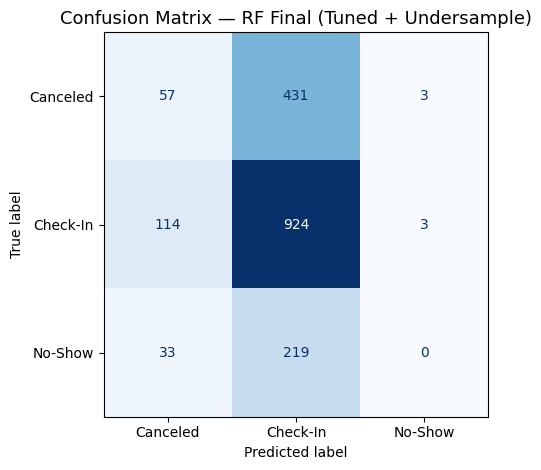

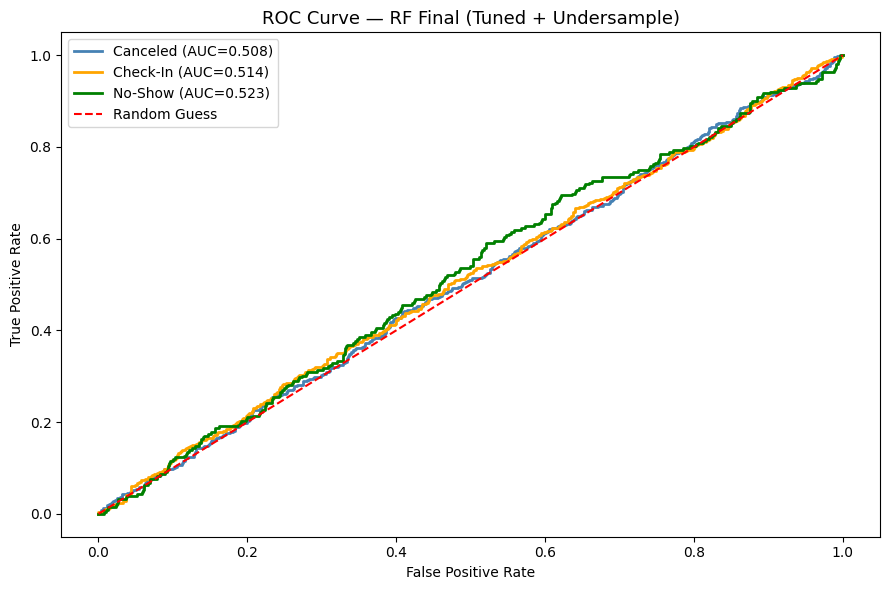


  Pre-tuning best F1 Macro:  0.3106 (RF Undersampling)
  Post-tuning F1 Macro:      0.2902
  Change:                    -0.0204


In [ ]:
# The best estimator from RandomizedSearchCV was already trained on
# undersampled data (X_train_rus, y_train_rus) — so it already has
# the undersampling baked in. We just evaluate on validation.

rf_final = rf_search.best_estimator_

print("Final model params:")
print(rf_final.get_params())
print(f"\nTrained on undersampled data: {X_train_rus.shape[0]} samples")

y_pred_final = rf_final.predict(X_val)
y_prob_final = rf_final.predict_proba(X_val)

metrics_final = evaluate_model("RF Final (Tuned + Undersample)", y_val, y_pred_final,
                                y_prob_final, y_val_bin, le_target.classes_)

# Compare against best pre-tuning result
print(f"\n{'='*55}")
print(f"  Pre-tuning best F1 Macro:  {results_df['f1_macro'].max():.4f} (RF Undersampling)")
print(f"  Post-tuning F1 Macro:      {metrics_final['f1_macro']:.4f}")
improvement = metrics_final['f1_macro'] - results_df['f1_macro'].max()
print(f"  Change:                    {improvement:+.4f}")
print(f"{'='*55}")

---
## **9. Feature Importance**

Top 15 Features by Importance:
          feature  importance
   Lead_Time_Days    0.104361
Total_Bill_amount    0.081755
        Room_Rate    0.080687
              Age    0.073494
        Meal_Type    0.057674
    Checkin_month    0.050085
    Booking_month    0.049022
Checkin_dayofweek    0.044121
Booking_dayofweek    0.042972
    Discount_Rate    0.038983
           Income    0.032243
Educational_Level    0.031436
     Total_Guests    0.021037
           Adults    0.019921
         Children    0.018419


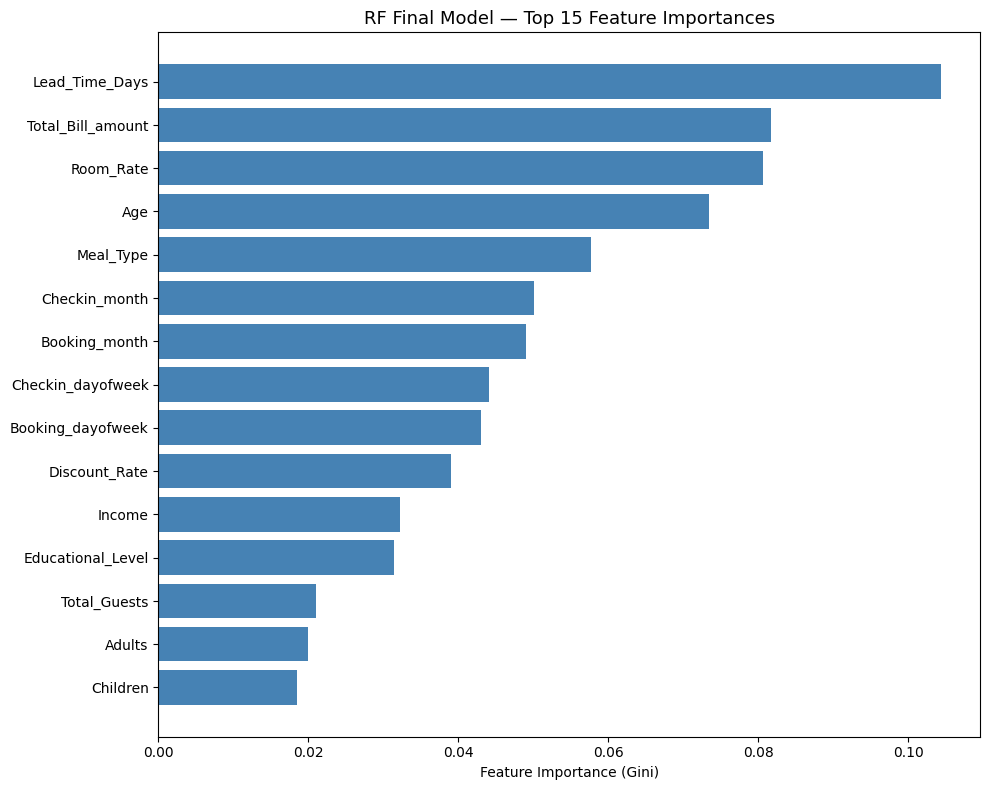


All features:
                    feature  importance
             Lead_Time_Days    0.104361
          Total_Bill_amount    0.081755
                  Room_Rate    0.080687
                        Age    0.073494
                  Meal_Type    0.057674
              Checkin_month    0.050085
              Booking_month    0.049022
          Checkin_dayofweek    0.044121
          Booking_dayofweek    0.042972
              Discount_Rate    0.038983
                     Income    0.032243
          Educational_Level    0.031436
               Total_Guests    0.021037
                     Adults    0.019921
                   Children    0.018419
                     Babies    0.018132
           Stay_Length_Days    0.017086
                     Gender    0.016459
    Deposit_type_Refundable    0.016042
       Country_region_South    0.015141
          Visted_Previously    0.014668
     Booking_channel_Online    0.014414
       Required_Car_Parking    0.014186
          Hotel_Type_Reso

In [ ]:
# Get feature importances from the final tuned model
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 Features by Importance:")
print(feat_imp.head(15).to_string(index=False))

# Plot top 15
plt.figure(figsize=(10, 8))
top15 = feat_imp.head(15)
plt.barh(top15["feature"][::-1], top15["importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance (Gini)")
plt.title("RF Final Model — Top 15 Feature Importances", fontsize=13)
plt.tight_layout()
plt.show()

# Full table
print("\nAll features:")
print(feat_imp.to_string(index=False))

---
## **10. Permutation Importance (Optional but stronger)**

Gini importance can be biased towards high-cardinality or continuous features. Permutation importance is a more reliable measure — it measures how much the score drops when you shuffle each feature.

In [ ]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance on validation set...")
perm_result = permutation_importance(
    rf_final, X_val, y_val,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 15 Features by Permutation Importance:")

print(perm_imp.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
top15_perm = perm_imp.head(15)
plt.barh(top15_perm["feature"][::-1], top15_perm["importance_mean"][::-1],
         xerr=top15_perm["importance_std"][::-1], color="darkorange")
plt.xlabel("Mean F1 Macro Decrease")
plt.title("RF Final Model — Permutation Importance (Top 15)", fontsize=13)
plt.tight_layout()
plt.show()

Computing permutation importance on validation set...


NameError: name 'rf_final' is not defined